<a href="https://colab.research.google.com/github/roses-and-thorns/BCS_Drowsiness_Detection/blob/main/Suicide_Rate_Based_Classification_IOHMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent State Modelling of Reddit Discourse Around IIT Suicides
### How does collective online behavior evolve after a suicide event at an IIT?

---

## Why are we doing this?

When a suicide is reported at an IIT, Reddit communities don't respond uniformly or statically.
There is a **pattern** that communities go through:

1. **Acute shock** (0–3 days): Raw reactions, information sharing, blame, urgent empathy
2. **Active discourse** (4–14 days): Organised accusations, policy discussion, mobilisation
3. **Absorption** (15–30 days): Reflection, personal mental health sharing, grief
4. **Recovery / fading** (31d+): Institutional discourse, residual speculation

The comment categories in this dataset are:
*S1 Sympathy, S2 Information, S3 Speculation, S4 Accusation/Blame, S5 Mobilisation,
S6 Indifference, S7 Irrelevant, S8 Personal Reflection, S9 Institutional Policy*

**Our goal**: Model the *proportion* of each category as a function of time since the
suicide event. We expect early phases to be dominated by **S4 Accusation** and **S2 Information**,
shifting toward **S1 Sympathy**, **S8 Personal Reflection**, and **S9 Institutional Policy** over time.

---

## Formal Setup

Let:
- **t** = time phase since incident (acute → active → absorbed → recovery)
- **X_t** = incident salience at time t (decays from 1 at t=0)
- **S_t** = latent collective response state at time t
- **B_t** = observed vector of category proportions at time t

We model:
```
P(S_t | S_{t-1}, X_t)   ← how states transition, driven by fading incident intensity
P(B_t | S_t)             ← what category proportions each state produces
```

This is an **Input-Output Hidden Markov Model (IOHMM)**, identical in structure
to the natural-disaster tweet model, adapted for Reddit suicide discourse.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.special import logsumexp
from scipy.optimize import minimize
from scipy.stats import mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 9})

In [ ]:
CATEGORY_ORDER = ["S1","S2","S3","S4","S5","S6","S7","S8","S9"]
CATEGORY_LABELS = {
    "S1": "Sympathy & Support",
    "S2": "Information Sharing",
    "S3": "Speculation / Cause",
    "S4": "Accusation / Blame",
    "S5": "Mobilization / Action",
    "S6": "Indifference / Low-effort",
    "S7": "Irrelevant",
    "S8": "Personal Reflection",
    "S9": "Institutional / Policy",
}
N_CATS = len(CATEGORY_ORDER)

PHASE_ORDER = ["acute", "active", "absorbed", "recovery"]
PHASE_DAYS  = {"acute": "0–3d", "active": "4–14d",
               "absorbed": "15–30d", "recovery": "31d+"}

COLORS = sns.color_palette("tab10", n_colors=N_CATS)

In [ ]:
HIGH_RATE_GROUP = ["IIT Bombay", "IIT Kanpur", "IIT Kharagpur"]
LOW_RATE_GROUP  = ["BITS", "VIT", "IIT Delhi"]

GROUP_COLORS = {"high": "#E84855", "low": "#2E86AB"}
GROUP_LABELS = {
    "high": "High-Rate (IIT-B, IIT-KGP, IIT-K)",
    "low":  "Low-Rate (BITS, VIT, IIT-D)"
}

print("Group definitions:")
print(f"  HIGH-rate [n=3]: {HIGH_RATE_GROUP}")
print(f"  LOW-rate  [n=3]: {LOW_RATE_GROUP}")
print()

Group definitions:
  HIGH-rate [n=3]: ['IIT Bombay', 'IIT Kanpur', 'IIT Kharagpur']
  LOW-rate  [n=3]: ['BITS', 'VIT', 'IIT Delhi']



# DATA LOADING

In [ ]:
df_raw = pd.read_csv("reddit_categorised.csv")
df_raw["datetime"]    = pd.to_datetime(df_raw["created_utc"], unit="s")
df_raw["institution"] = df_raw["institution"].astype(str).str.strip()

INCIDENT_ANCHORS = {
    "BITS":          pd.Timestamp("2025-03-03"),
    "IIT Bombay":    pd.Timestamp("2026-02-02"),
    "IIT Delhi":     pd.Timestamp("2026-03-09"),
    "IIT Kanpur":    pd.Timestamp("2025-12-29"),
    "IIT Kharagpur": pd.Timestamp("2026-04-13"),
    "VIT":           pd.Timestamp("2025-07-17"),
}

WINDOW_BEFORE = 7
WINDOW_AFTER  = 180

rows = []
for inst, anchor in INCIDENT_ANCHORS.items():
    grp = df_raw[df_raw["institution"] == inst].copy()
    for _, row in grp.iterrows():
        days = (row["datetime"] - anchor).total_seconds() / 86400
        if -WINDOW_BEFORE <= days <= WINDOW_AFTER:
            row2 = row.copy()
            row2["incident_id"]         = inst
            row2["anchor_date"]         = anchor
            row2["days_since_incident"] = days
            # ── NEW: assign group ──────────────────────────────────────────
            row2["rate_group"] = (
                "high" if inst in HIGH_RATE_GROUP else "low"
            )
            rows.append(row2)

df = pd.DataFrame(rows).reset_index(drop=True)

bins   = [-WINDOW_BEFORE - 0.01, 3, 14, 30, WINDOW_AFTER + 1]
df["time_phase"] = pd.cut(df["days_since_incident"],
                           bins=bins, labels=PHASE_ORDER)
df["time_phase"] = pd.Categorical(df["time_phase"],
                                   categories=PHASE_ORDER, ordered=True)

lam = np.log(2) / 7.0
df["incident_salience"] = np.exp(
    -lam * df["days_since_incident"].clip(lower=0)
)

print(f"Dataset: {len(df):,} comments")
print()
print("Comments per group:")
print(df.groupby("rate_group")["comment_id"].count())
print()
print("Incidents per group:")
print(df.groupby(["rate_group","incident_id"]).size().unstack(fill_value=0))

Dataset: 2,297 comments

Comments per group:
rate_group
high    1727
low      570
Name: comment_id, dtype: int64

Incidents per group:
incident_id  BITS  IIT Bombay  IIT Delhi  IIT Kanpur  IIT Kharagpur  VIT
rate_group                                                              
high            0         290          0         486            951    0
low           190           0        114           0              0  266


# GROUP-LEVEL PROPORTION COMPUTATION

In [ ]:
def compute_proportions(df_subset, label=""):
    """Compute (incident, phase, category) proportions for a dataframe slice."""
    prop = (
        df_subset
        .groupby(["incident_id", "time_phase", "category_code"], observed=True)
        .size()
        .reset_index(name="count")
    )
    phase_totals = (
        df_subset
        .groupby(["incident_id", "time_phase"], observed=True)
        .size()
        .reset_index(name="phase_total")
    )
    prop = prop.merge(phase_totals, on=["incident_id","time_phase"])
    prop["proportion"] = prop["count"] / prop["phase_total"]
    prop["time_phase"] = pd.Categorical(
        prop["time_phase"], categories=PHASE_ORDER, ordered=True
    )
    return prop


def aggregate_proportions(prop_df):
    """Mean ± SE across incidents."""
    agg = (
        prop_df
        .groupby(["time_phase","category_code"], observed=True)["proportion"]
        .agg(["mean","std","count"])
        .reset_index()
    )
    agg["se"]         = agg["std"] / np.sqrt(agg["count"])
    agg["time_phase"] = pd.Categorical(
        agg["time_phase"], categories=PHASE_ORDER, ordered=True
    )
    return agg.sort_values(["category_code","time_phase"])


df_high = df[df["rate_group"] == "high"]
df_low  = df[df["rate_group"] == "low"]

prop_high = compute_proportions(df_high, "high")
prop_low  = compute_proportions(df_low,  "low")

agg_high = aggregate_proportions(prop_high)
agg_low  = aggregate_proportions(prop_low)

print("High-rate group — mean proportions:")
piv_high = agg_high.pivot_table(
    index="category_code", columns="time_phase", values="mean", aggfunc="first"
)
piv_high.index = [f"{c}: {CATEGORY_LABELS[c]}" for c in piv_high.index]
print(piv_high.round(3).to_string())
print()
print("Low-rate group — mean proportions:")
piv_low = agg_low.pivot_table(
    index="category_code", columns="time_phase", values="mean", aggfunc="first"
)
piv_low.index = [f"{c}: {CATEGORY_LABELS[c]}" for c in piv_low.index]
print(piv_low.round(3).to_string())


High-rate group — mean proportions:
time_phase                     acute  active  absorbed  recovery
S1: Sympathy & Support         0.070   0.051     0.167       NaN
S2: Information Sharing        0.153   0.107     0.295     0.138
S3: Speculation / Cause        0.155   0.192     0.182     0.172
S4: Accusation / Blame         0.156   0.210     0.273     0.207
S5: Mobilization / Action      0.025   0.047     0.091       NaN
S6: Indifference / Low-effort  0.111   0.123     0.106     0.103
S7: Irrelevant                 0.209   0.218     0.220     0.345
S8: Personal Reflection        0.026   0.041       NaN     0.034
S9: Institutional / Policy     0.106   0.034     0.045       NaN

Low-rate group — mean proportions:
time_phase                     acute  active  recovery
S1: Sympathy & Support         0.090   0.110     0.063
S2: Information Sharing        0.164   0.136     0.153
S3: Speculation / Cause        0.090   0.210     0.128
S4: Accusation / Blame         0.209   0.117     0.264
S5:

# SIDE-BY-SIDE PROPORTION TRAJECTORIES

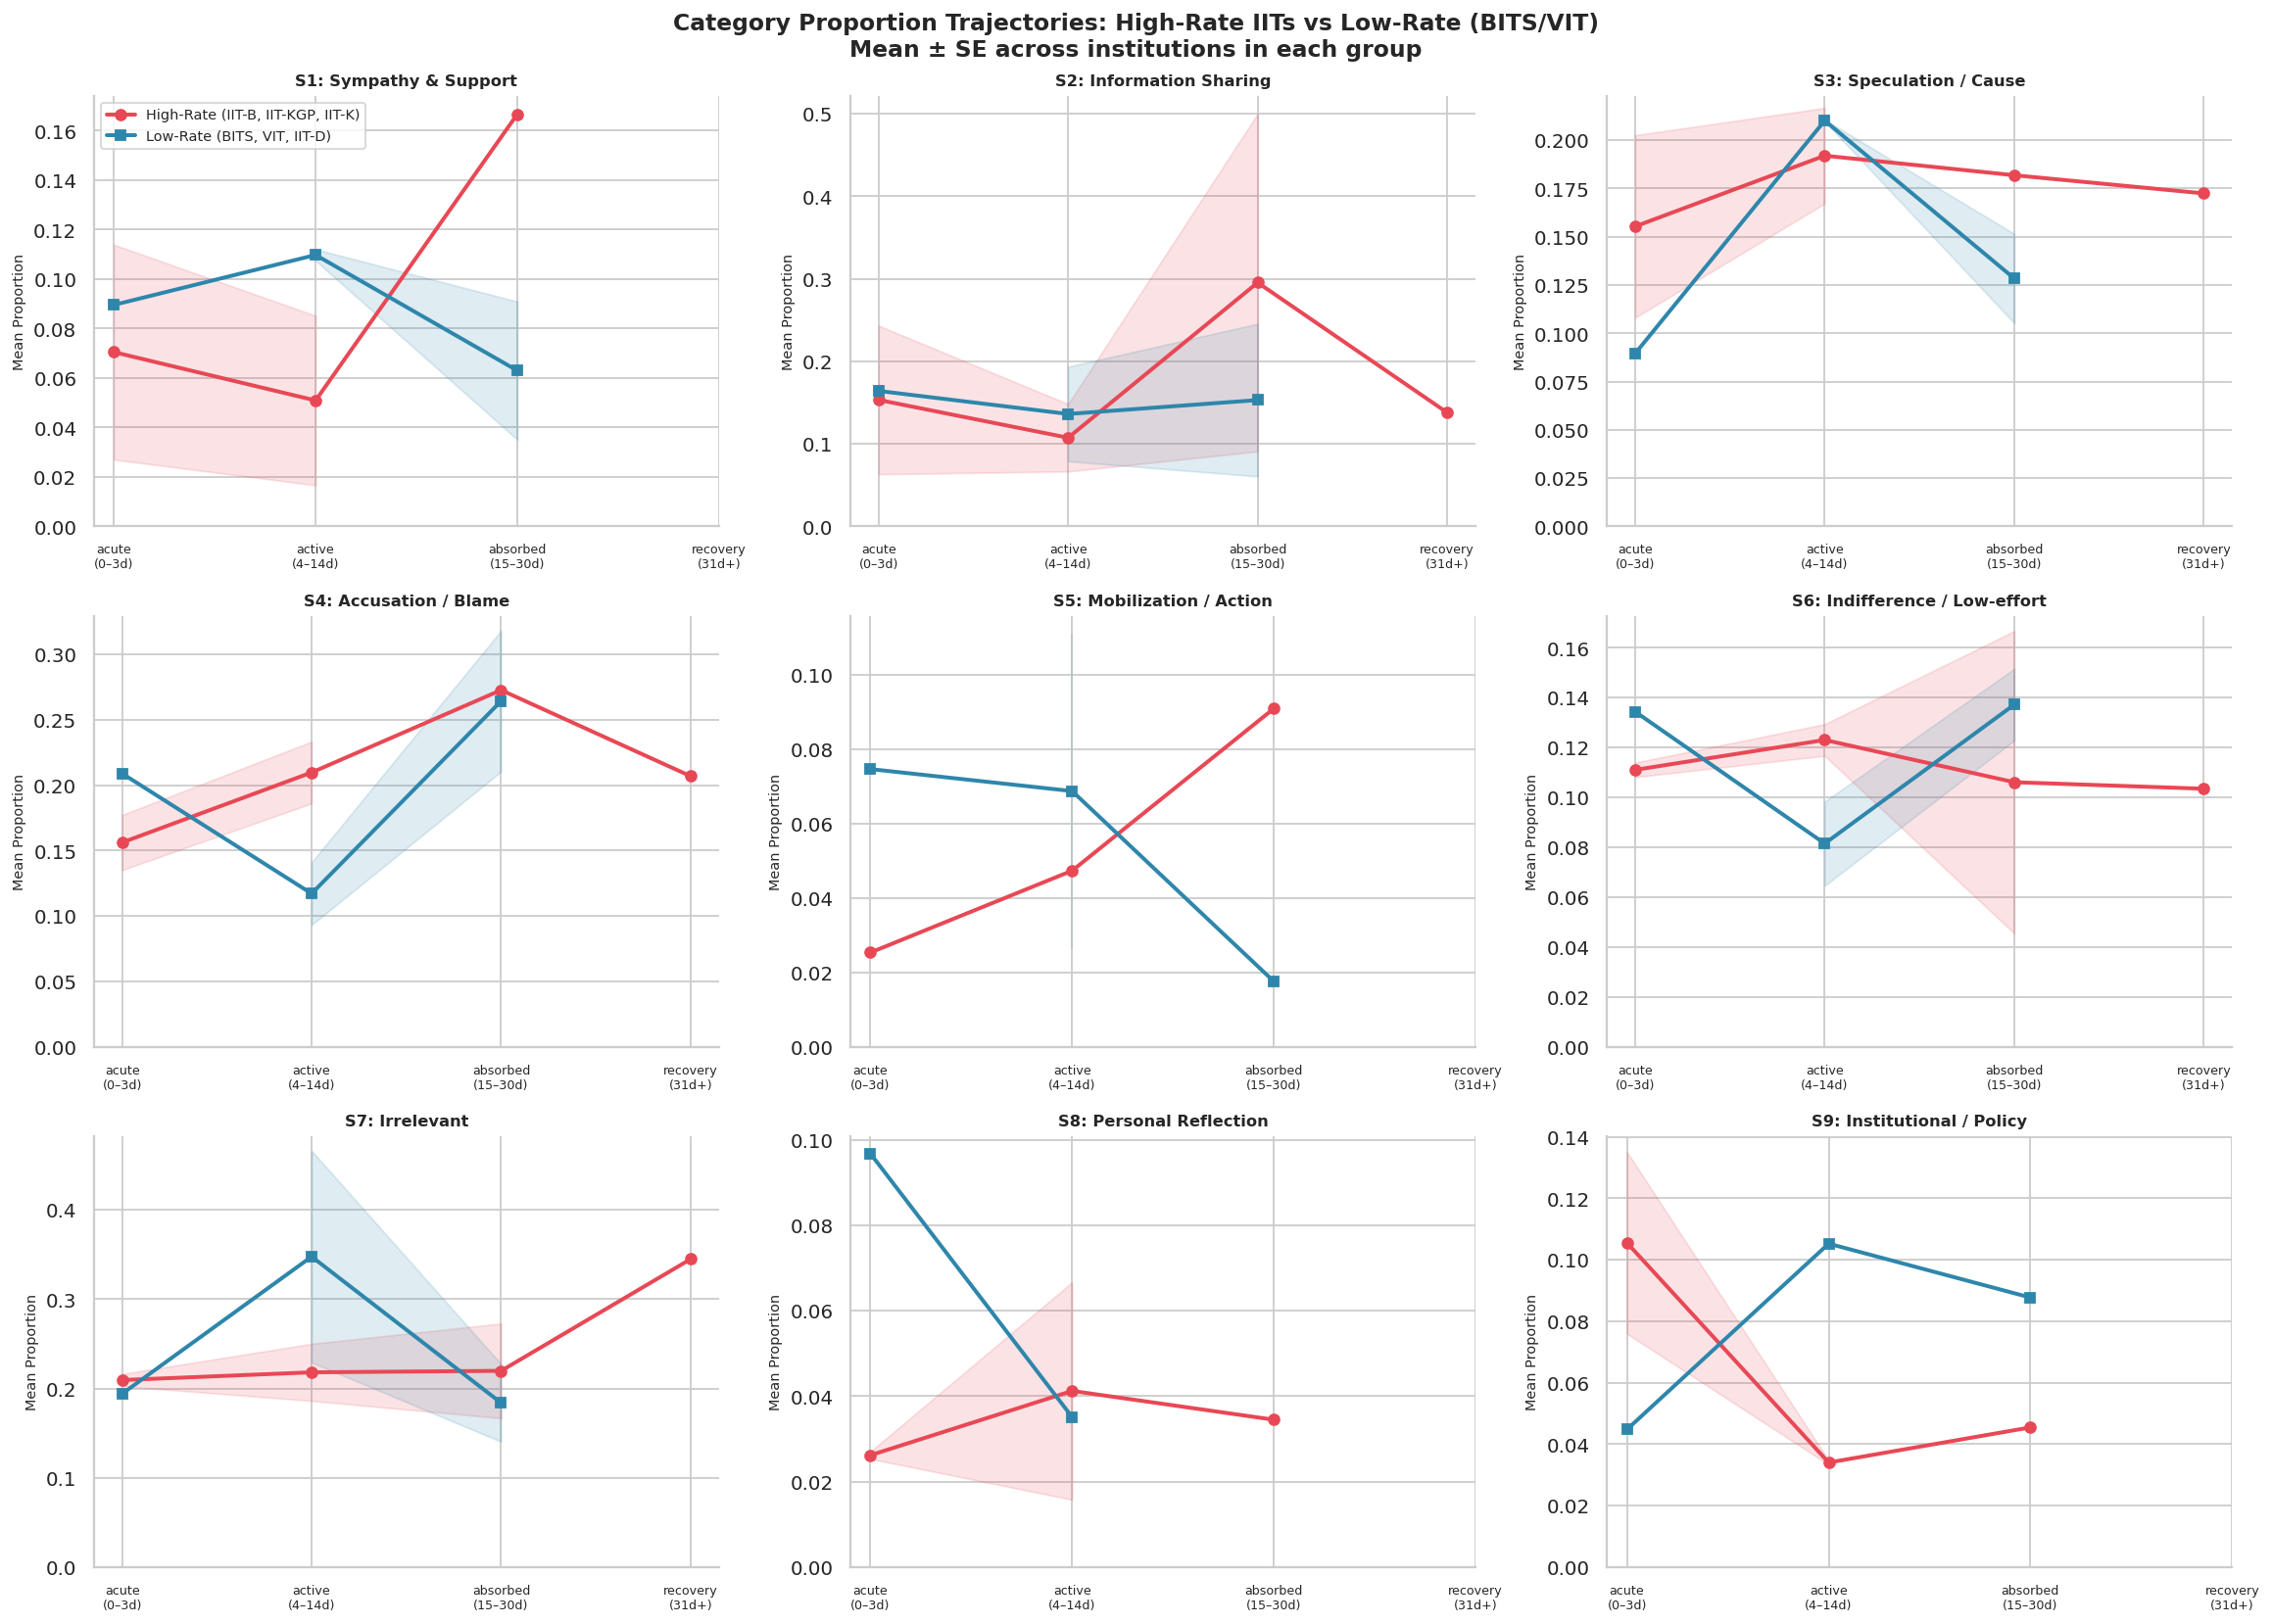

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharey=False)
axes = axes.ravel()

phase_xlabels = [f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]

for d, cat in enumerate(CATEGORY_ORDER):
    ax = axes[d]
    for grp_key, agg_df, marker in [("high", agg_high, "o"), ("low", agg_low, "s")]:
        sub = agg_df[agg_df["category_code"] == cat].sort_values("time_phase")
        if len(sub) == 0:
            continue
        x = np.arange(len(sub))
        ax.plot(x, sub["mean"],
                marker=marker, linewidth=2.2, markersize=6,
                color=GROUP_COLORS[grp_key],
                label=GROUP_LABELS[grp_key])
        ax.fill_between(x,
                        sub["mean"] - sub["se"],
                        sub["mean"] + sub["se"],
                        alpha=0.15, color=GROUP_COLORS[grp_key])

    ax.set_xticks(range(4))
    ax.set_xticklabels(phase_xlabels, fontsize=7)
    ax.set_title(f"{cat}: {CATEGORY_LABELS[cat]}", fontsize=9, fontweight="bold")
    ax.set_ylabel("Mean Proportion", fontsize=8)
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if d == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    "Category Proportion Trajectories: High-Rate IITs vs Low-Rate (BITS/VIT)\n"
    "Mean ± SE across institutions in each group",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mn_fig_grp1_proportion_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()



# STACKED AREA COMPARISON (side-by-side)

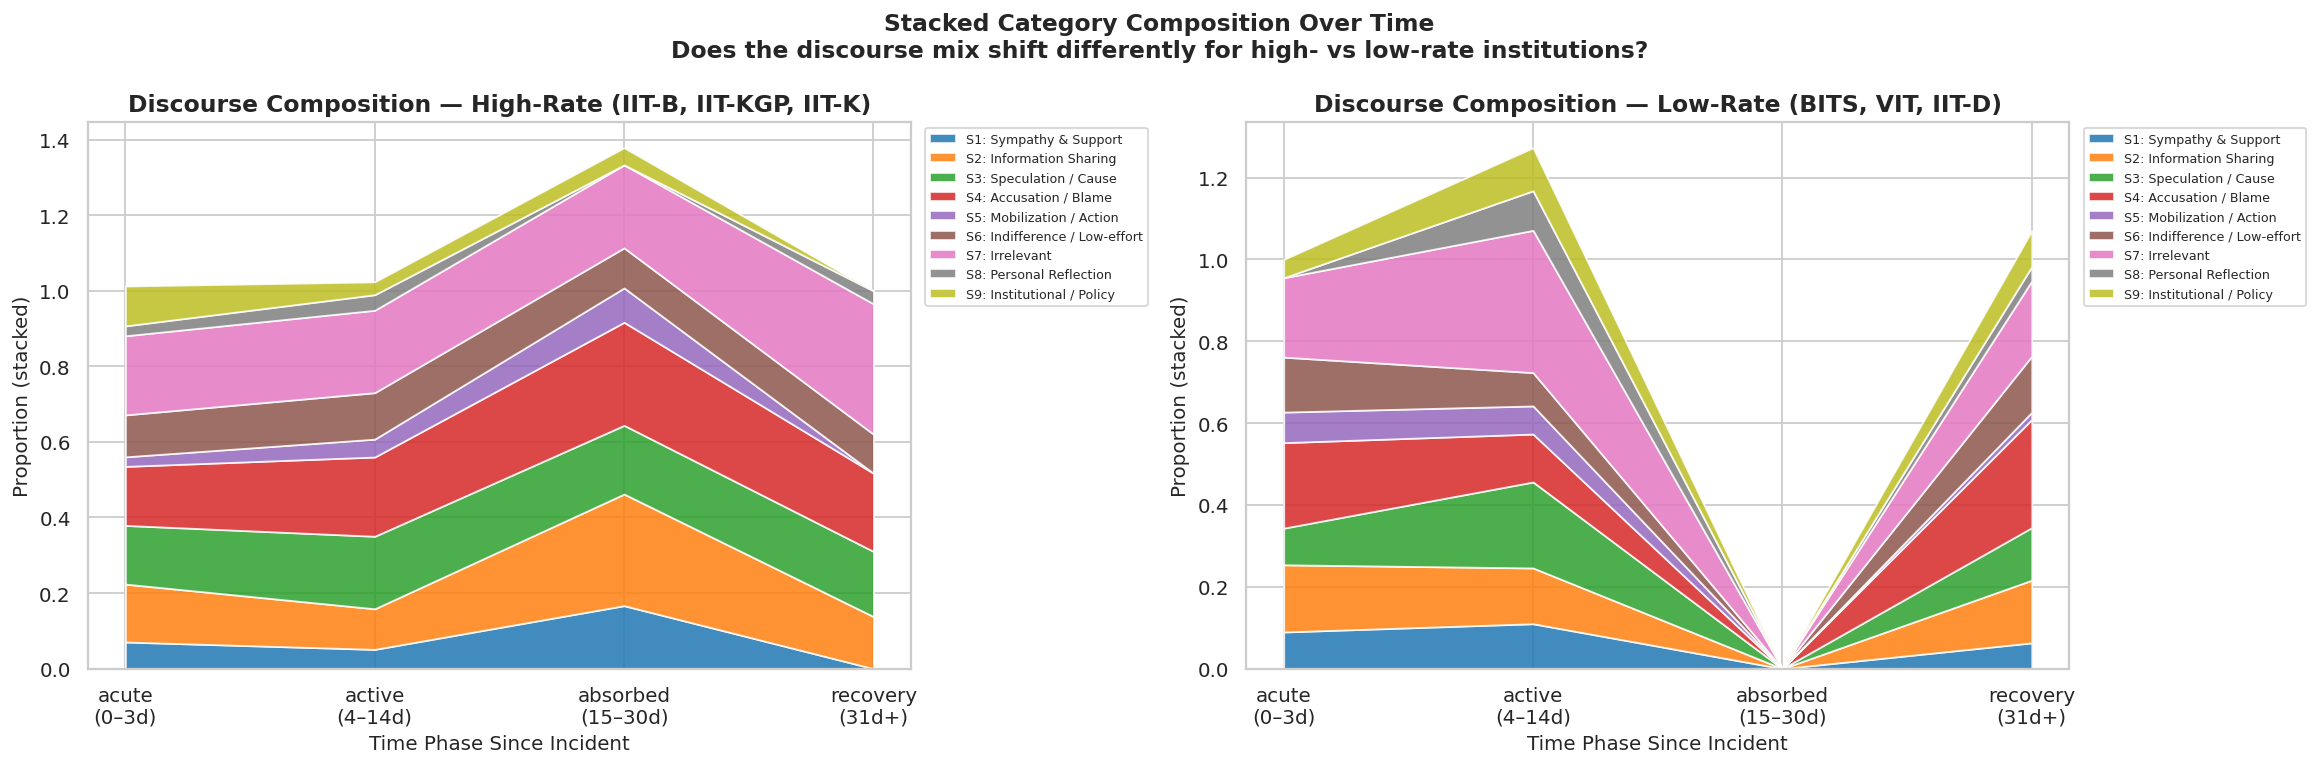

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, agg_df, grp_key in [(axes[0], agg_high, "high"),
                             (axes[1], agg_low,  "low")]:
    pivot_area = agg_df.pivot_table(
        index="time_phase", columns="category_code",
        values="mean", aggfunc="first"
    )

    pivot_area = pivot_area.reindex(index=PHASE_ORDER, columns=CATEGORY_ORDER).fillna(0.0)

    n_phases = len(pivot_area)
    y = pivot_area.values.T
    x = np.arange(n_phases)
    ax.stackplot(x, y,
                 labels=[f"{c}: {CATEGORY_LABELS[c]}" for c in CATEGORY_ORDER],
                 colors=COLORS, alpha=0.85)
    ax.set_xticks(range(n_phases))
    ax.set_xticklabels([phase_xlabels[i] for i in range(n_phases)])
    ax.set_xlabel("Time Phase Since Incident")
    ax.set_ylabel("Proportion (stacked)")
    ax.set_title(
        f"Discourse Composition — {GROUP_LABELS[grp_key]}",
        fontweight="bold"
    )
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

plt.suptitle(
    "Stacked Category Composition Over Time\n"
    "Does the discourse mix shift differently for high- vs low-rate institutions?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mn_fig_grp2_stacked_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# DIFFERENCE HEATMAP  (high − low)

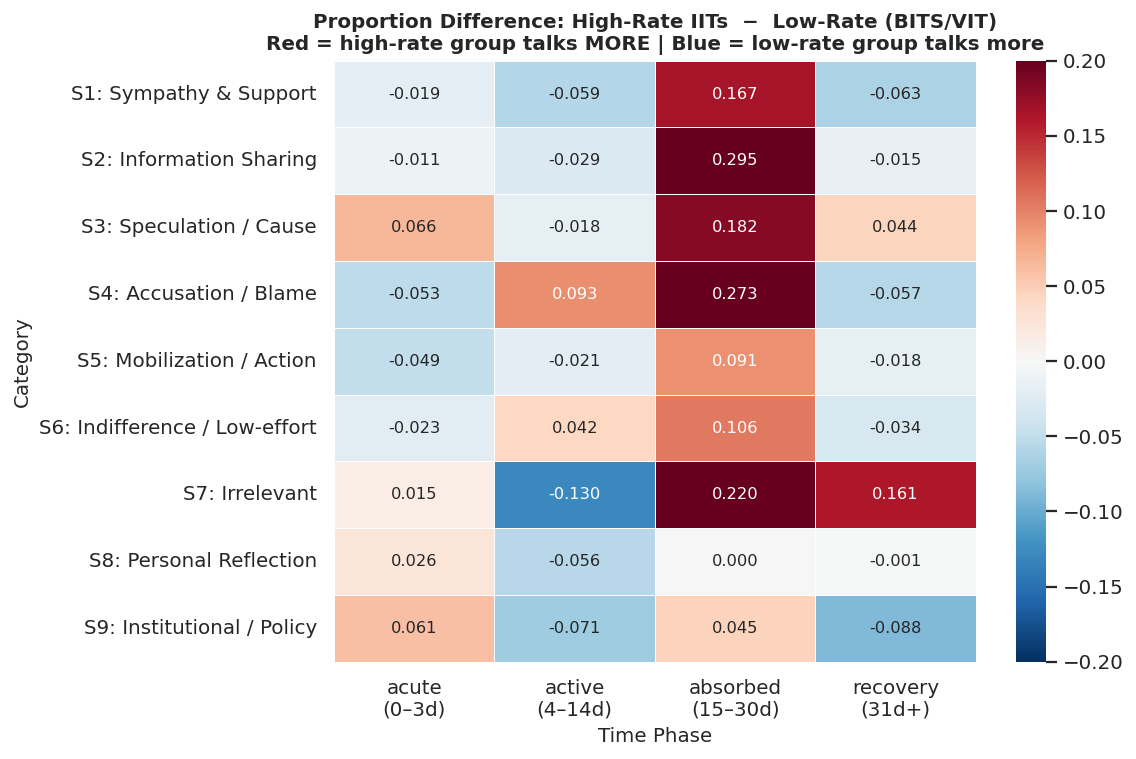

In [ ]:
pivot_h = agg_high.pivot_table(
    index="category_code", columns="time_phase", values="mean", aggfunc="first"
).reindex(index=CATEGORY_ORDER, columns=PHASE_ORDER).fillna(0)

pivot_l = agg_low.pivot_table(
    index="category_code", columns="time_phase", values="mean", aggfunc="first"
).reindex(index=CATEGORY_ORDER, columns=PHASE_ORDER).fillna(0)

diff_pivot = pivot_h - pivot_l

fig, ax = plt.subplots(figsize=(9, 6))
diff_pivot.index = [f"{c}: {CATEGORY_LABELS[c]}" for c in diff_pivot.index]

sns.heatmap(
    diff_pivot, ax=ax,
    cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
    annot=True, fmt=".3f", annot_kws={"size": 9},
    linewidths=0.4,
    xticklabels=[f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]
)
ax.set_title(
    "Proportion Difference: High-Rate IITs  −  Low-Rate (BITS/VIT)\n"
    "Red = high-rate group talks MORE | Blue = low-rate group talks more",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Time Phase")
ax.set_ylabel("Category")

plt.tight_layout()
plt.savefig("mn_fig_grp3_difference_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()




# STATISTICAL TESTS: Mann-Whitney U per category per phase


Mann-Whitney U tests: High vs Low group per category per phase
(p < 0.05 = significant difference; small n → treat as exploratory)

Significant differences (p<0.05): 0
Empty DataFrame
Columns: [phase, category, mean_high, mean_low, diff, p_value]
Index: []


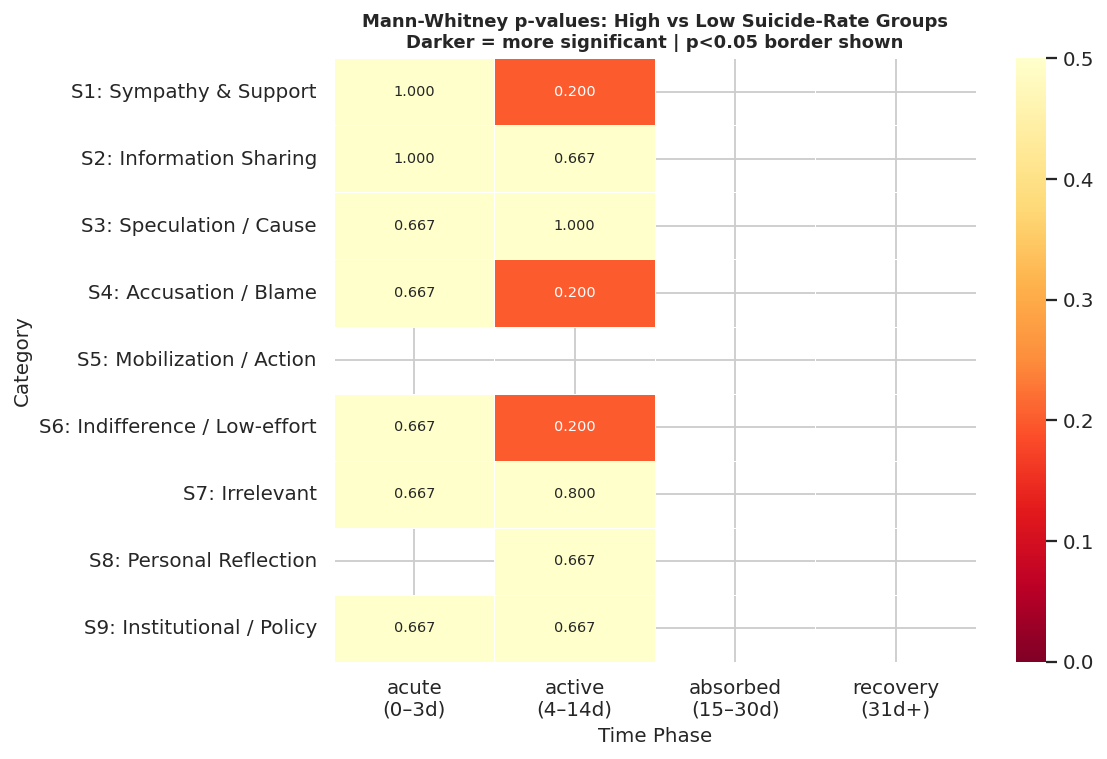

In [ ]:

print("\nMann-Whitney U tests: High vs Low group per category per phase")
print("(p < 0.05 = significant difference; small n → treat as exploratory)\n")

stat_rows = []
for phase in PHASE_ORDER:
    for cat in CATEGORY_ORDER:
        hi_vals = prop_high[
            (prop_high["time_phase"] == phase) &
            (prop_high["category_code"] == cat)
        ]["proportion"].values

        lo_vals = prop_low[
            (prop_low["time_phase"] == phase) &
            (prop_low["category_code"] == cat)
        ]["proportion"].values

        if len(hi_vals) >= 2 and len(lo_vals) >= 1:
            try:
                stat, p = mannwhitneyu(hi_vals, lo_vals, alternative="two-sided")
            except Exception:
                stat, p = np.nan, np.nan
        else:
            stat, p = np.nan, np.nan

        stat_rows.append({
            "phase": phase, "category": cat,
            "mean_high": hi_vals.mean() if len(hi_vals) > 0 else np.nan,
            "mean_low":  lo_vals.mean() if len(lo_vals) > 0 else np.nan,
            "diff":      (hi_vals.mean() - lo_vals.mean())
                         if (len(hi_vals) > 0 and len(lo_vals) > 0) else np.nan,
            "p_value": p
        })

stat_df = pd.DataFrame(stat_rows)
sig = stat_df[stat_df["p_value"] < 0.05].sort_values("p_value")
print(f"Significant differences (p<0.05): {len(sig)}")
print(sig[["phase","category","mean_high","mean_low","diff","p_value"]].round(4).to_string(index=False))

# Heatmap of p-values
pval_pivot = stat_df.pivot_table(
    index="category", columns="phase", values="p_value", aggfunc="first"
).reindex(index=CATEGORY_ORDER, columns=PHASE_ORDER)

fig, ax = plt.subplots(figsize=(9, 6))
pval_pivot.index = [f"{c}: {CATEGORY_LABELS[c]}" for c in pval_pivot.index]
sns.heatmap(
    pval_pivot, ax=ax,
    cmap="YlOrRd_r", vmin=0, vmax=0.5,
    annot=True, fmt=".3f", annot_kws={"size": 8},
    linewidths=0.4,
    xticklabels=[f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]
)
ax.set_title(
    "Mann-Whitney p-values: High vs Low Suicide-Rate Groups\n"
    "Darker = more significant | p<0.05 border shown",
    fontsize=10, fontweight="bold"
)
ax.set_xlabel("Time Phase")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("mn_fig_grp4_pvalue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# IOHMM CLASS

In [ ]:
class IOHMM:
    def __init__(self, n_states=3, n_obs=9, random_state=42):
        self.K   = n_states
        self.D   = n_obs
        self.rng = np.random.default_rng(random_state)

    def _n_params(self):
        return self.K + self.K*self.K + self.K*self.K + self.K*self.D

    def _unpack(self, params):
        K, D = self.K, self.D
        i = 0
        log_pi = params[i:i+K];               i += K
        W_A    = params[i:i+K*K].reshape(K,K); i += K*K
        v_A    = params[i:i+K*K].reshape(K,K); i += K*K
        log_B  = params[i:i+K*D].reshape(K,D)
        return log_pi, W_A, v_A, log_B

    def _init_params(self):
        K, D = self.K, self.D
        log_pi = np.zeros(K)
        W_A    = self.rng.normal(0, 0.3, (K, K))
        v_A    = self.rng.normal(0, 0.3, (K, K))
        log_B  = self.rng.normal(0, 0.3, (K, D))
        return np.concatenate([log_pi, W_A.ravel(), v_A.ravel(), log_B.ravel()])

    def _transition(self, W_A, v_A, x_t):
        logits = W_A + v_A * x_t
        logits -= logits.max(axis=1, keepdims=True)
        A = np.exp(logits)
        A /= A.sum(axis=1, keepdims=True)
        return A

    def _log_emission(self, log_B, obs_vec):
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        return log_B_norm @ obs_vec

    def _forward(self, params, obs_seq, int_seq):
        log_pi, W_A, v_A, log_B = self._unpack(params)
        T, K = len(obs_seq), self.K
        alpha = np.full((T, K), -np.inf)
        pi       = log_pi - logsumexp(log_pi)
        alpha[0] = pi + self._log_emission(log_B, obs_seq[0])
        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-300)
            for j in range(K):
                alpha[t, j] = logsumexp(alpha[t-1] + log_A[:, j]) + \
                               self._log_emission(log_B, obs_seq[t])[j]
        return logsumexp(alpha[-1]), alpha

    def _neg_log_lik(self, params):
        total = 0.0
        for obs_seq, int_seq in zip(self._fit_seqs, self._fit_ints):
            ll, _ = self._forward(params, obs_seq, int_seq)
            total += ll
        return -total

    def fit(self, sequences, intensities, n_restarts=8, verbose=True):
        self._fit_seqs = sequences
        self._fit_ints = intensities
        best_ll, best_params = -np.inf, None
        for r in range(n_restarts):
            p0 = self._init_params() + self.rng.normal(0, 0.1, self._n_params())
            try:
                res = minimize(self._neg_log_lik, p0,
                               method="L-BFGS-B",
                               options={"maxiter": 500, "ftol": 1e-9})
                ll = -res.fun
                if verbose:
                    print(f"  restart {r+1}/{n_restarts}: ll={ll:.4f}")
                if ll > best_ll:
                    best_ll, best_params = ll, res.x
            except Exception as e:
                if verbose:
                    print(f"  restart {r+1} failed: {e}")
        self.params_  = best_params
        self.log_lik_ = best_ll
        log_pi, W_A, v_A, log_B = self._unpack(best_params)
        self.pi_     = np.exp(log_pi - logsumexp(log_pi))
        self.A_base_ = self._transition(W_A, v_A, 0.0)
        self.A_high_ = self._transition(W_A, v_A, 1.0)
        log_B_norm   = log_B - logsumexp(log_B, axis=1, keepdims=True)
        self.B_      = np.exp(log_B_norm)
        return self

    def decode(self, obs_seq, int_seq):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        T, K = len(obs_seq), self.K
        viterbi = np.full((T, K), -np.inf)
        backptr  = np.zeros((T, K), dtype=int)
        pi           = log_pi - logsumexp(log_pi)
        viterbi[0]   = pi + self._log_emission(log_B, obs_seq[0])
        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-300)
            for j in range(K):
                scores       = viterbi[t-1] + log_A[:, j]
                backptr[t,j] = np.argmax(scores)
                viterbi[t,j] = scores[backptr[t,j]] + \
                               self._log_emission(log_B, obs_seq[t])[j]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(viterbi[-1])
        for t in range(T-2, -1, -1):
            path[t] = backptr[t+1, path[t+1]]
        return path

    def aic(self):
        return 2 * self._n_params() - 2 * self.log_lik_

    def bic(self, n_obs):
        return self._n_params() * np.log(n_obs) - 2 * self.log_lik_

    def simulate(self, int_seq, n_trials=50):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        T = len(int_seq)
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        B = np.exp(log_B_norm)
        pi = np.exp(log_pi - logsumexp(log_pi))
        all_states, all_obs = [], []
        for _ in range(n_trials):
            states, obs = [], []
            s = self.rng.choice(self.K, p=pi)
            states.append(s)
            obs.append(B[s])
            for t in range(1, T):
                A = self._transition(W_A, v_A, int_seq[t])
                s = self.rng.choice(self.K, p=A[s])
                states.append(s)
                obs.append(B[s])
            all_states.append(states)
            all_obs.append(obs)
        return all_states, all_obs

print("IOHMM class ready.")


IOHMM class ready.


# BUILD SEQUENCES PER GROUP

In [ ]:
def build_sequences(df_subset, prop_df):
    sequences, intensities, incident_names = [], [], []
    mean_sal = (
        df_subset
        .groupby(["incident_id","time_phase"], observed=True)["incident_salience"]
        .mean()
        .reset_index()
    )
    for inc in sorted(df_subset["incident_id"].unique()):
        seq, intv = [], []
        for phase in PHASE_ORDER:
            sub_prop = prop_df[
                (prop_df["incident_id"] == inc) &
                (prop_df["time_phase"] == phase)
            ]
            sub_sal = mean_sal[
                (mean_sal["incident_id"] == inc) &
                (mean_sal["time_phase"] == phase)
            ]
            if len(sub_prop) == 0 or len(sub_sal) == 0:
                continue
            obs_vec = np.zeros(N_CATS)
            for _, row in sub_prop.iterrows():
                if row["category_code"] in CATEGORY_ORDER:
                    idx = CATEGORY_ORDER.index(row["category_code"])
                    obs_vec[idx] = row["proportion"]
            obs_vec /= (obs_vec.sum() + 1e-9)
            seq.append(obs_vec)
            intv.append(sub_sal["incident_salience"].values[0])
        if len(seq) >= 2:
            sequences.append(np.array(seq))
            intensities.append(np.array(intv))
            incident_names.append(inc)
    return sequences, intensities, incident_names


seqs_high, ints_high, names_high = build_sequences(df_high, prop_high)
seqs_low,  ints_low,  names_low  = build_sequences(df_low,  prop_low)

print(f"High-rate sequences usable: {len(seqs_high)}  →  {names_high}")
print(f"Low-rate  sequences usable: {len(seqs_low)}   →  {names_low}")

High-rate sequences usable: 2  →  ['IIT Bombay', 'IIT Kanpur']
Low-rate  sequences usable: 2   →  ['BITS', 'VIT']


#  MODEL SELECTION PER GROUP (K = 2, 3)


Model selection for HIGH-rate group (IIT-B, IIT-KGP, IIT-K)...
  K=2
  restart 1/8: ll=-11.6031
  restart 2/8: ll=-11.6031
  restart 3/8: ll=-11.6031
  restart 4/8: ll=-11.6031
  restart 5/8: ll=-11.6031
  restart 6/8: ll=-11.6031
  restart 7/8: ll=-11.6031
  restart 8/8: ll=-11.6031
  → LL=-11.60  AIC=79.21  BIC=73.38

  K=3
  restart 1/8: ll=-11.1292
  restart 2/8: ll=-11.1292
  restart 3/8: ll=-11.1292
  restart 4/8: ll=-11.1292
  restart 5/8: ll=-11.6031
  restart 6/8: ll=-11.1292
  restart 7/8: ll=-11.1292
  restart 8/8: ll=-11.1292
  → LL=-11.13  AIC=118.26  BIC=108.26

Selected K=2 for HIGH-rate group.

Model selection for LOW-rate group (BITS, VIT, IIT-Delhi)...
  K=2
  restart 1/8: ll=-9.4128
  restart 2/8: ll=-9.4128
  restart 3/8: ll=-9.4128
  restart 4/8: ll=-9.4128
  restart 5/8: ll=-9.4128
  restart 6/8: ll=-9.4128
  restart 7/8: ll=-9.4128
  restart 8/8: ll=-9.4128
  → LL=-9.41  AIC=74.83  BIC=63.89

  K=3
  restart 1/8: ll=-9.3399
  restart 2/8: ll=-9.4128
  restart 3/

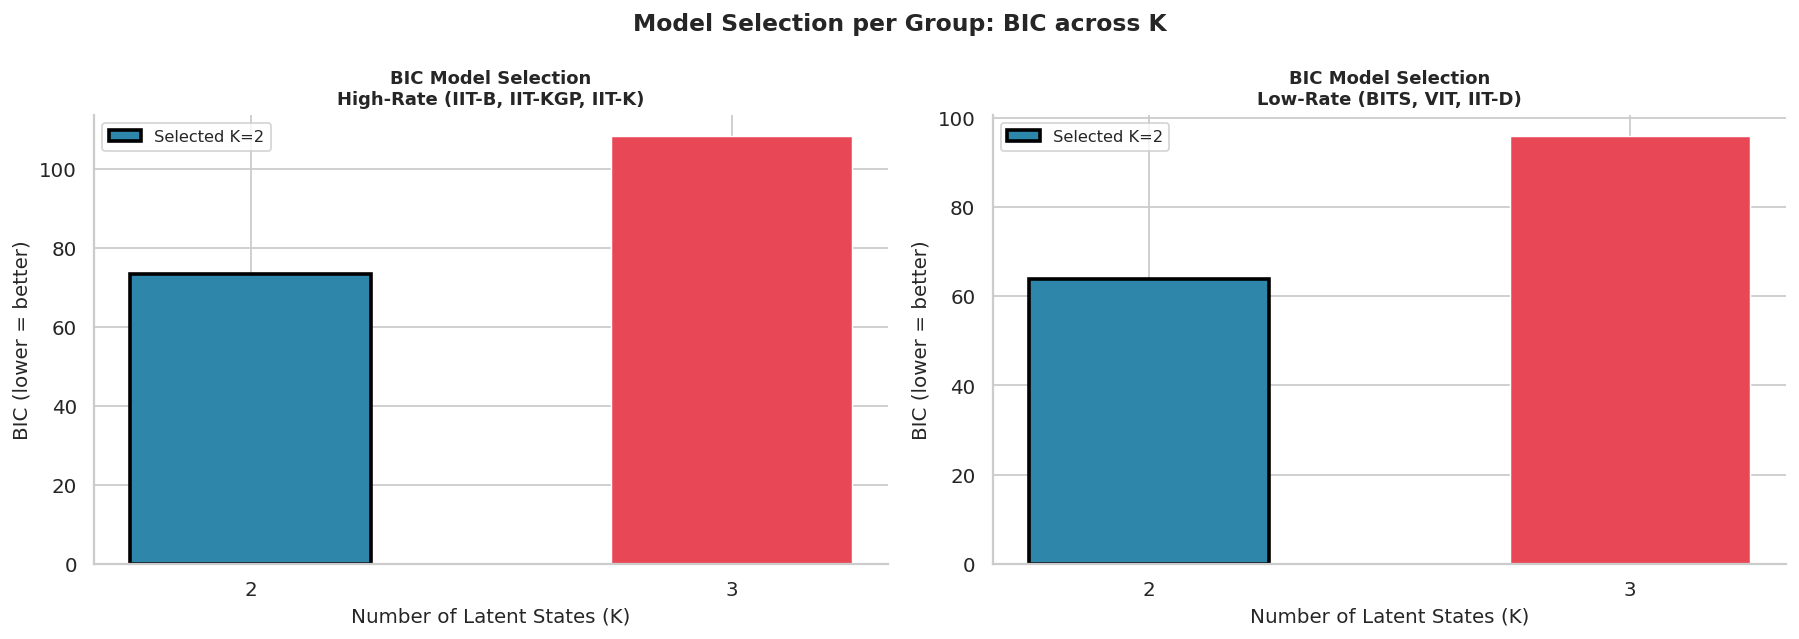

In [ ]:
print("\nModel selection for HIGH-rate group (IIT-B, IIT-KGP, IIT-K)...")
high_fit_results = {}
for K in [2, 3]:
    print(f"  K={K}")
    m = IOHMM(n_states=K, n_obs=N_CATS, random_state=42)
    m.fit(seqs_high, ints_high, n_restarts=8, verbose=True)
    n_obs = sum(len(s) for s in seqs_high)
    high_fit_results[K] = {"model": m, "ll": m.log_lik_,
                            "AIC": m.aic(), "BIC": m.bic(n_obs)}
    print(f"  → LL={m.log_lik_:.2f}  AIC={m.aic():.2f}  BIC={m.bic(n_obs):.2f}\n")

best_K_high = min(high_fit_results, key=lambda k: high_fit_results[k]["BIC"])
model_high  = high_fit_results[best_K_high]["model"]
print(f"Selected K={best_K_high} for HIGH-rate group.\n")


print("Model selection for LOW-rate group (BITS, VIT, IIT-Delhi)...")
low_fit_results = {}
for K in [2, 3]:
    print(f"  K={K}")
    m = IOHMM(n_states=K, n_obs=N_CATS, random_state=42)
    m.fit(seqs_low, ints_low, n_restarts=8, verbose=True)
    n_obs = sum(len(s) for s in seqs_low)
    low_fit_results[K] = {"model": m, "ll": m.log_lik_,
                           "AIC": m.aic(), "BIC": m.bic(n_obs)}
    print(f"  → LL={m.log_lik_:.2f}  AIC={m.aic():.2f}  BIC={m.bic(n_obs):.2f}\n")

best_K_low = min(low_fit_results, key=lambda k: low_fit_results[k]["BIC"])
model_low  = low_fit_results[best_K_low]["model"]
print(f"Selected K={best_K_low} for LOW-rate group.\n")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Ks = [2, 3]
palette = {2: "#2E86AB", 3: "#E84855"}
bar_cols = [palette[k] for k in Ks]

for ax, (grp_key, fit_res, best_K) in zip(
        axes,
        [("high", high_fit_results, best_K_high),
         ("low",  low_fit_results,  best_K_low)]):
    bic_vals = [fit_res[k]["BIC"] for k in Ks]
    bars = ax.bar(Ks, bic_vals, color=bar_cols, edgecolor="white", linewidth=0.8,
                  width=0.5)
    ax.bar(best_K, fit_res[best_K]["BIC"],
           color=palette[best_K], edgecolor="black", linewidth=2, width=0.5,
           label=f"Selected K={best_K}")
    ax.set_xticks(Ks)
    ax.set_xlabel("Number of Latent States (K)")
    ax.set_ylabel("BIC (lower = better)")
    ax.set_title(f"BIC Model Selection\n{GROUP_LABELS[grp_key]}",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Model Selection per Group: BIC across K", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mn_fig_grp_modelsel.png", dpi=150, bbox_inches="tight")
plt.show()

# EMISSION MATRIX SIDE-BY-SIDE

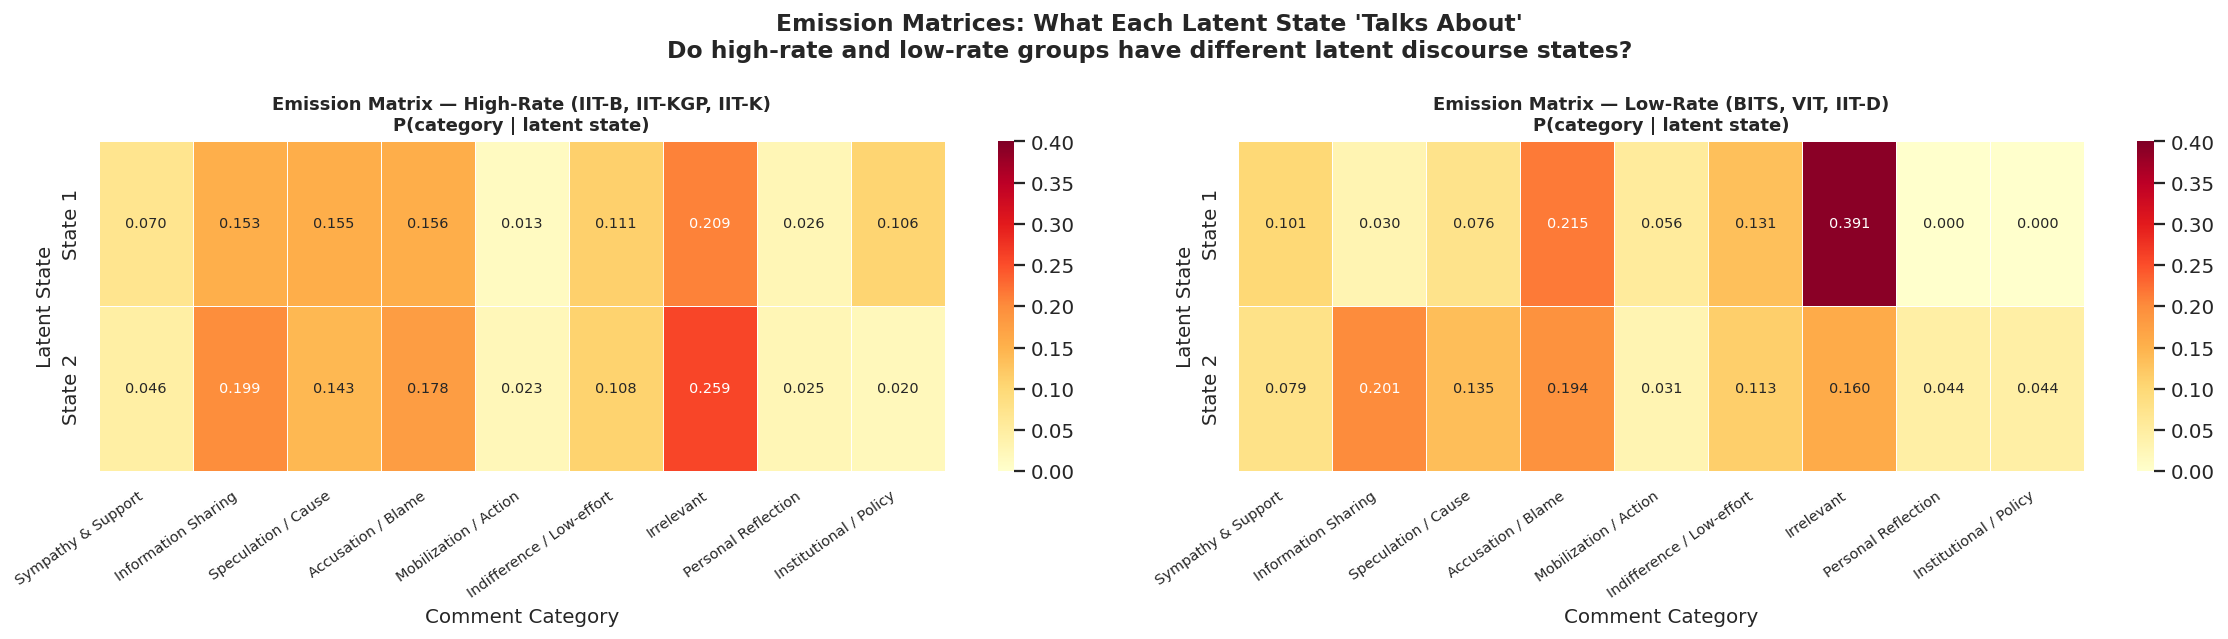

In [ ]:
cat_full      = [CATEGORY_LABELS[c] for c in CATEGORY_ORDER]
state_names_h = [f"State {k+1}" for k in range(model_high.K)]
state_names_l = [f"State {k+1}" for k in range(model_low.K)]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, model, state_names, grp_key in [
        (axes[0], model_high, state_names_h, "high"),
        (axes[1], model_low,  state_names_l, "low")]:
    B_df = pd.DataFrame(model.B_, columns=cat_full, index=state_names)
    sns.heatmap(B_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=0.4,
                annot_kws={"size": 8})
    ax.set_title(
        f"Emission Matrix — {GROUP_LABELS[grp_key]}\n"
        f"P(category | latent state)",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Comment Category")
    ax.set_ylabel("Latent State")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)

plt.suptitle(
    "Emission Matrices: What Each Latent State 'Talks About'\n"
    "Do high-rate and low-rate groups have different latent discourse states?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mn_fig_grp5_emission_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# KL DIVERGENCE BETWEEN GROUP EMISSION PROFILES

In [ ]:
def kl_divergence(p, q, eps=1e-9):
    """KL(p || q): how much information is lost using q to describe p."""
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return float(np.sum(p * np.log(p / q)))

print("\nKL Divergence: High-rate states vs Low-rate states")
print("(Lower = more similar discourse; Higher = structurally different)\n")
for kh in range(model_high.K):
    for kl in range(model_low.K):
        kl_val = kl_divergence(model_high.B_[kh], model_low.B_[kl])
        print(f"  KL( High State {kh+1} || Low State {kl+1} ) = {kl_val:.4f}")


KL Divergence: High-rate states vs Low-rate states
(Lower = more similar discourse; Higher = structurally different)

  KL( High State 1 || Low State 1 ) = 2.4293
  KL( High State 1 || Low State 2 ) = 0.0607
  KL( High State 2 || Low State 1 ) = 0.9273
  KL( High State 2 || Low State 2 ) = 0.0493


# TRANSITION MATRICES COMPARISON


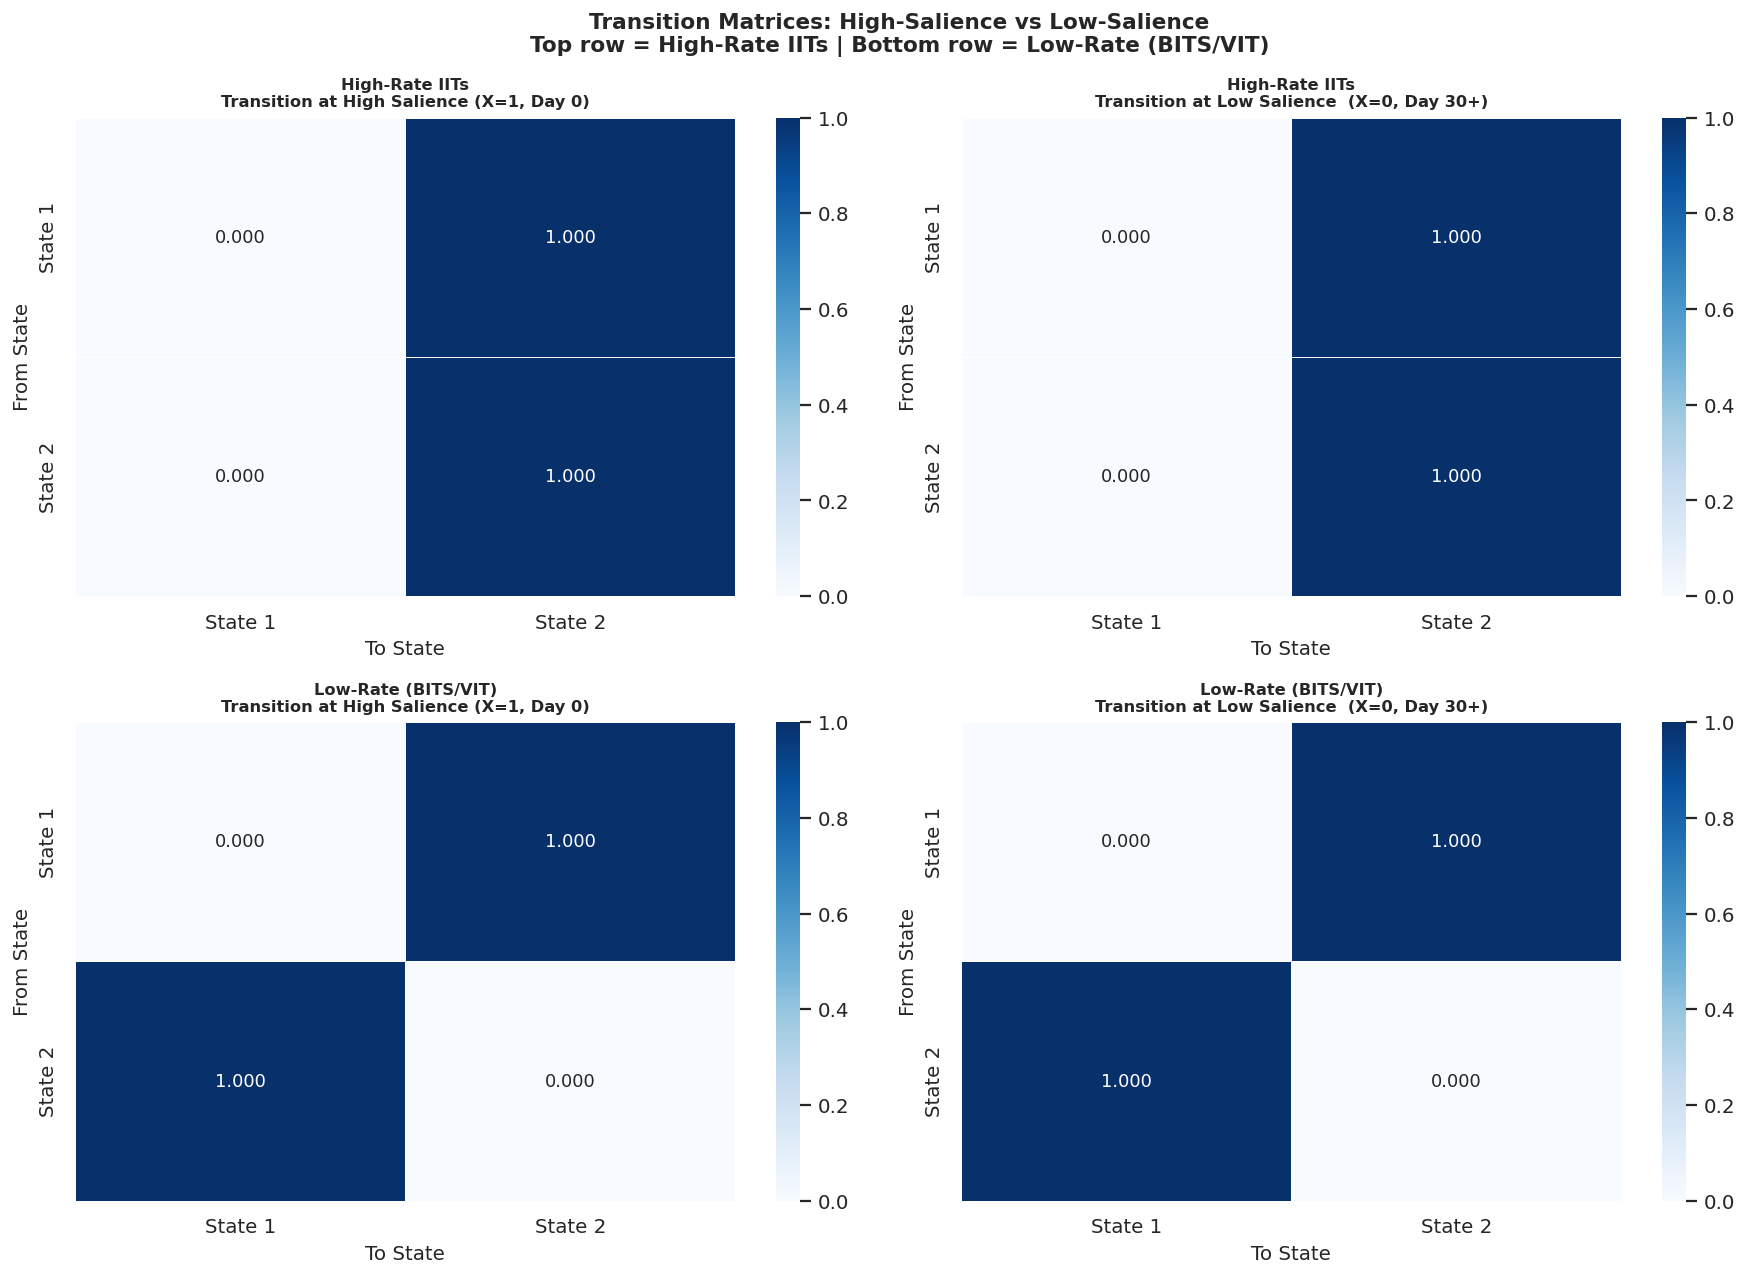

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = [
    ("High-Rate IITs\nTransition at High Salience (X=1, Day 0)", "high", "A_high_"),
    ("High-Rate IITs\nTransition at Low Salience  (X=0, Day 30+)", "high", "A_base_"),
    ("Low-Rate (BITS/VIT)\nTransition at High Salience (X=1, Day 0)", "low", "A_high_"),
    ("Low-Rate (BITS/VIT)\nTransition at Low Salience  (X=0, Day 30+)", "low", "A_base_"),
]

for ax, (title, grp_key, attr) in zip(axes.ravel(), titles):
    model_ref  = model_high if grp_key == "high" else model_low
    snames     = state_names_h if grp_key == "high" else state_names_l
    A          = getattr(model_ref, attr)
    A_df       = pd.DataFrame(A, index=snames, columns=snames)
    sns.heatmap(A_df, annot=True, fmt=".3f", cmap="Blues",
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                annot_kws={"size": 10})
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_xlabel("To State")
    ax.set_ylabel("From State")

plt.suptitle(
    "Transition Matrices: High-Salience vs Low-Salience\n"
    "Top row = High-Rate IITs | Bottom row = Low-Rate (BITS/VIT)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mn_fig_grp6_transition_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# VITERBI DECODED TRAJECTORIES PER GROUP

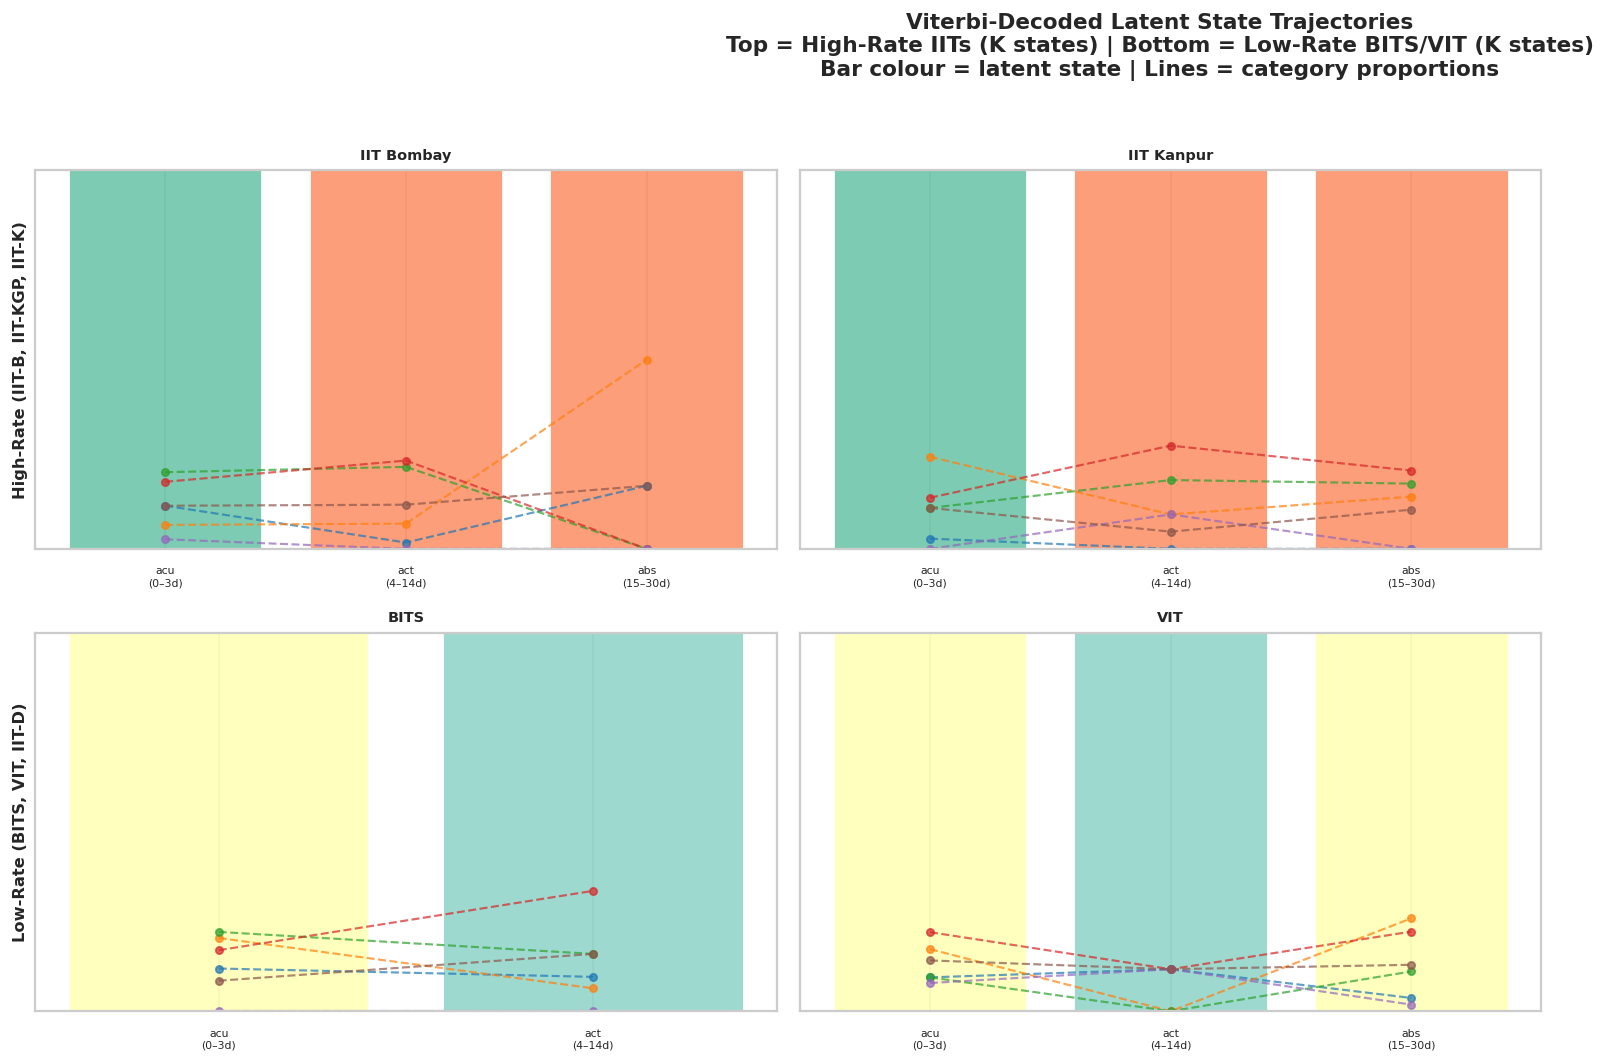

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
group_configs = [
    ("high", names_high, seqs_high, ints_high, model_high, state_names_h),
    ("low",  names_low,  seqs_low,  ints_low,  model_low,  state_names_l),
]
state_palette = [sns.color_palette("Set2", n_colors=model_high.K),
                 sns.color_palette("Set3", n_colors=model_low.K)]

for row_idx, (grp_key, names, seqs, ints, model, snames) in enumerate(group_configs):
    state_colors = state_palette[row_idx]
    for col_idx, (inc, seq, intv) in enumerate(zip(names, seqs, ints)):
        ax = axes[row_idx, col_idx]
        path = model.decode(seq, intv)
        T    = len(path)
        for t in range(T):
            ax.bar(t, 1, color=state_colors[path[t]],
                   alpha=0.85, edgecolor="white", linewidth=0.5)
        for d, cat in enumerate(CATEGORY_ORDER[:6]):
            if d < seq.shape[1]:
                ax.plot(range(T), seq[:T, d], "o--",
                        linewidth=1.2, markersize=4,
                        color=COLORS[d], alpha=0.7, label=cat)
        ax.set_title(f"{inc}", fontsize=8, fontweight="bold")
        ax.set_xticks(range(T))
        ax.set_xticklabels([f"{p[:3]}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER[:T]],
                           fontsize=6)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xlabel("")


    for col_idx in range(len(names), 3):
        axes[row_idx, col_idx].set_visible(False)


    axes[row_idx, 0].set_ylabel(
        GROUP_LABELS[grp_key], fontsize=9, fontweight="bold", rotation=90
    )

plt.suptitle(
    "Viterbi-Decoded Latent State Trajectories\n"
    "Top = High-Rate IITs (K states) | Bottom = Low-Rate BITS/VIT (K states)\n"
    "Bar colour = latent state | Lines = category proportions",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("mn_fig_grp7_viterbi_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()


# CROSS-GROUP PREDICTIVE CHECK

In [ ]:
print("\nCross-group predictive check:")
print("Trained on HIGH (IIT-B, IIT-KGP, IIT-K) → evaluate on LOW (BITS, VIT, IIT-D)")
print("Trained on LOW  (BITS, VIT, IIT-D)       → evaluate on HIGH (IIT-B, IIT-KGP, IIT-K)")
print()


ll_hi_on_lo = sum(
    model_high._forward(model_high.params_, s, v)[0]
    for s, v in zip(seqs_low, ints_low)
)

ll_lo_on_hi = sum(
    model_low._forward(model_low.params_, s, v)[0]
    for s, v in zip(seqs_high, ints_high)
)

print(f"  High model on high data (train LL): {model_high.log_lik_:.3f}")
print(f"  High model on low  data:            {ll_hi_on_lo:.3f}")
delta_h = model_high.log_lik_ - ll_hi_on_lo
print(f"  ΔLL                                 {delta_h:.3f}  {'← substantial gap = groups structurally differ' if abs(delta_h) > 1 else '← small gap = similar dynamics'}")
print()
print(f"  Low model on low  data (train LL):  {model_low.log_lik_:.3f}")
print(f"  Low model on high data:             {ll_lo_on_hi:.3f}")
delta_l = model_low.log_lik_ - ll_lo_on_hi
print(f"  ΔLL                                 {delta_l:.3f}  {'← substantial gap = groups structurally differ' if abs(delta_l) > 1 else '← small gap = similar dynamics'}")


Cross-group predictive check:
Trained on HIGH (IIT-B, IIT-KGP, IIT-K) → evaluate on LOW (BITS, VIT, IIT-D)
Trained on LOW  (BITS, VIT, IIT-D)       → evaluate on HIGH (IIT-B, IIT-KGP, IIT-K)

  High model on high data (train LL): -11.603
  High model on low  data:            -10.130
  ΔLL                                 -1.473  ← substantial gap = groups structurally differ

  Low model on low  data (train LL):  -9.413
  Low model on high data:             -14.247
  ΔLL                                 4.834  ← substantial gap = groups structurally differ


# SUMMARY COMPARISON BAR CHART

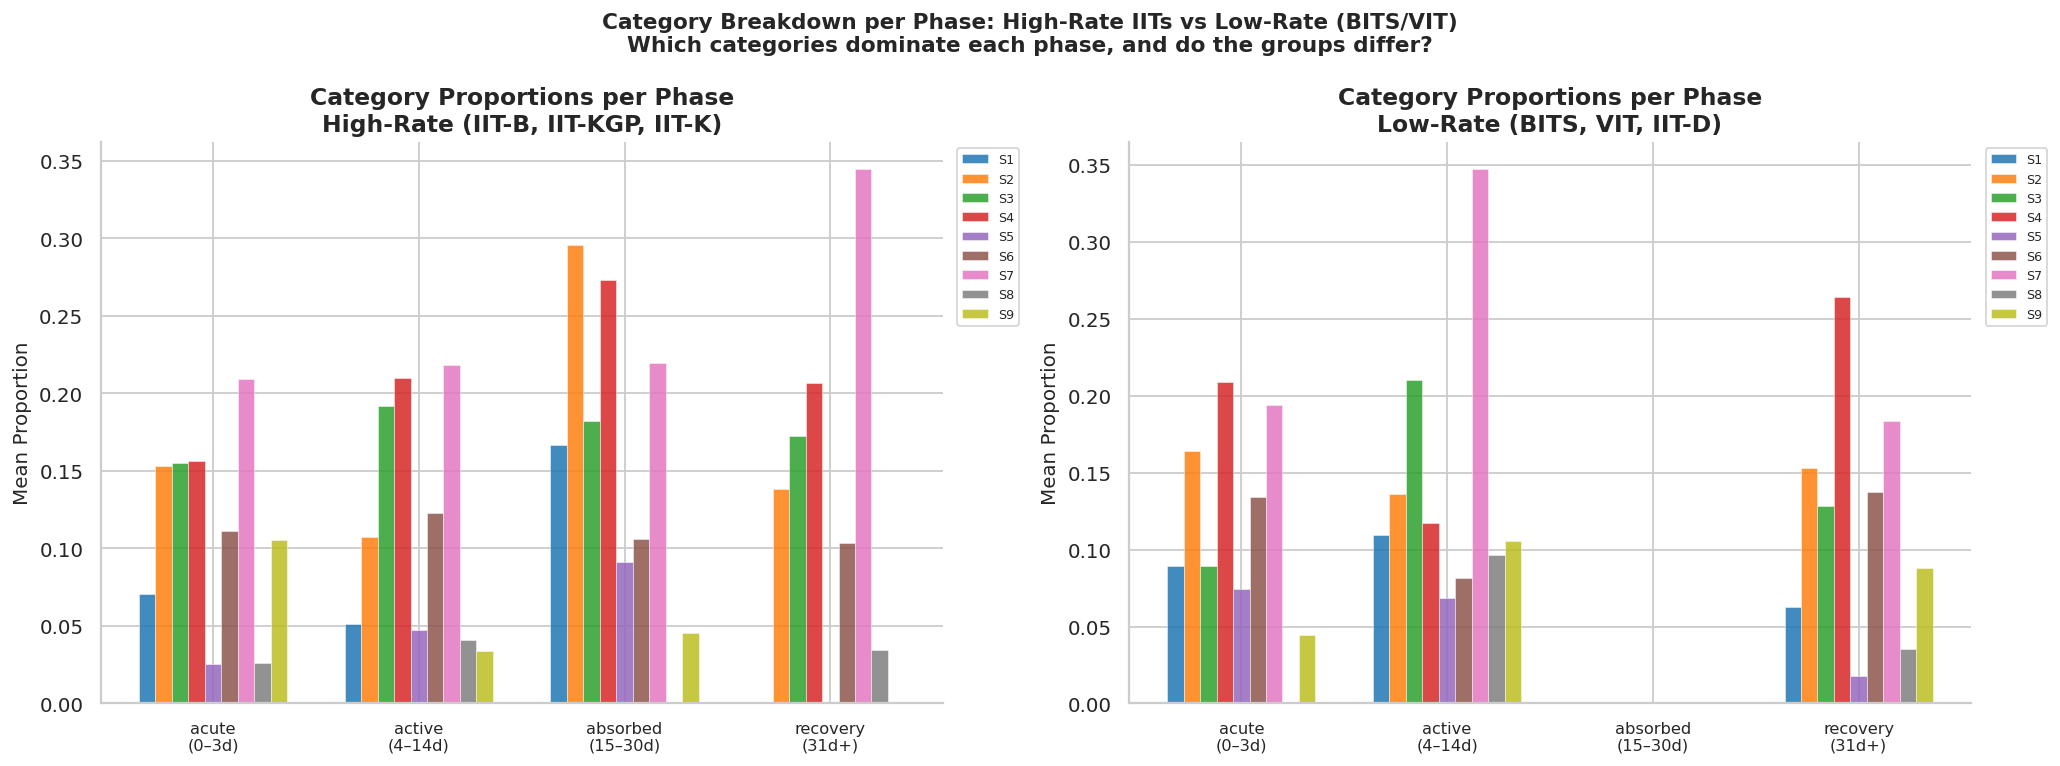


All group-comparison figures saved.
Files generated:
  mn_fig_grp_modelsel.png          — BIC model selection per group
  mn_fig_grp1_proportion_trajectories.png — per-category trajectories, both groups
  mn_fig_grp2_stacked_comparison.png      — stacked area composition side-by-side
  mn_fig_grp3_difference_heatmap.png      — high − low proportion difference
  mn_fig_grp4_pvalue_heatmap.png          — Mann-Whitney p-values
  mn_fig_grp5_emission_comparison.png     — emission matrices per group
  mn_fig_grp6_transition_comparison.png   — transition matrices (high/low salience)
  mn_fig_grp7_viterbi_trajectories.png    — Viterbi decoded arcs
  mn_fig_grp8_phase_category_bars.png     — summary grouped bar chart


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
phase_xlabels_short = [f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]

for ax, agg_df, grp_key in [(axes[0], agg_high, "high"),
                             (axes[1], agg_low,  "low")]:
    pivot = agg_df.pivot_table(
        index="time_phase", columns="category_code",
        values="mean", aggfunc="first"
    ).reindex(index=PHASE_ORDER, columns=CATEGORY_ORDER).fillna(0)

    x    = np.arange(len(PHASE_ORDER))
    w    = 0.08
    for d, cat in enumerate(CATEGORY_ORDER):
        offset = (d - N_CATS / 2 + 0.5) * w
        ax.bar(x + offset, pivot[cat].values,
               width=w, label=f"{cat}", color=COLORS[d],
               alpha=0.85, edgecolor="white", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(phase_xlabels_short, fontsize=9)
    ax.set_ylabel("Mean Proportion")
    ax.set_title(f"Category Proportions per Phase\n{GROUP_LABELS[grp_key]}",
                 fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Category Breakdown per Phase: High-Rate IITs vs Low-Rate (BITS/VIT)\n"
    "Which categories dominate each phase, and do the groups differ?",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mn_fig_grp8_phase_category_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll group-comparison figures saved.")
print("Files generated:")
labels = [
    "mn_fig_grp_modelsel.png          — BIC model selection per group",
    "mn_fig_grp1_proportion_trajectories.png — per-category trajectories, both groups",
    "mn_fig_grp2_stacked_comparison.png      — stacked area composition side-by-side",
    "mn_fig_grp3_difference_heatmap.png      — high − low proportion difference",
    "mn_fig_grp4_pvalue_heatmap.png          — Mann-Whitney p-values",
    "mn_fig_grp5_emission_comparison.png     — emission matrices per group",
    "mn_fig_grp6_transition_comparison.png   — transition matrices (high/low salience)",
    "mn_fig_grp7_viterbi_trajectories.png    — Viterbi decoded arcs",
    "mn_fig_grp8_phase_category_bars.png     — summary grouped bar chart",
]
for l in labels:
    print(f"  {l}")
